# 02. Формирование признаков и baseline-модель, определить state и action RL-агента

В этом ноутбуке рассчитаем признаки для модели и реализуем baseline-стратегию на основе Z-score базиса между спотовым и фьючерсным инструментами.

По условию задания необходимо:
- рассчитать доходности, волатильность и корреляцию
- сформировать набор признаков для модели
- реализовать базовую торговую стратегию
- провести бэктестинг
- оценить результаты стратегии

В качестве торговой пары используем:
- **BTC-USDT** — спотовый инструмент,
- **XBTUSDTM** — бессрочный фьючерс на тот же актив.

Далее используем ранее выгруженные и объединённые данные из `data/raw`.

In [14]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
src_path = str((repo_root / "src").resolve())
config_path = repo_root / "config" / "basis_strategy_config.json"

if src_path not in sys.path:
    sys.path.insert(0, src_path)

from crypto_rl_bot.features import (
    calculate_core_metrics,
    build_feature_dataset,
    save_processed_dataset,
)
from crypto_rl_bot.baseline import backtest_zscore_strategy, format_baseline_results
from crypto_rl_bot.config import load_config

print("Корень проекта:", repo_root)
print("Путь к конфигу:", config_path)

Корень проекта: /Users/coyc_kari/Final_project_MLfr_team5
Путь к конфигу: /Users/coyc_kari/Final_project_MLfr_team5/config/basis_strategy_config.json


In [15]:
cfg = load_config(config_path)

print("Спот:", cfg.data.spot_symbol)
print("Фьючерс:", cfg.data.futures_symbol)
print("Интервал:", cfg.data.interval)
print("Горизонт baseline, месяцев:", cfg.data.baseline_history_months)
print("Горизонт RL, лет:", cfg.data.rl_history_years)

Спот: BTC-USDT
Фьючерс: XBTUSDTM
Интервал: 1day
Горизонт baseline, месяцев: 6
Горизонт RL, лет: 2


## Загрузим baseline-датасет

Для baseline-модели используем объединённый датасет со спотовыми и фьючерсными ценами.  
Далее на его основе рассчитаем базовые метрики ряда и подготовим признаки.

In [16]:
raw_dir = repo_root / cfg.data.raw_dir

baseline_files = sorted(raw_dir.glob("baseline_*_merged.parquet"))
if not baseline_files:
    raise FileNotFoundError("Не найден файл baseline_*_merged.parquet в data/raw")

baseline_path = baseline_files[-1]
print("Используем файл:", baseline_path.name)

df = pd.read_parquet(baseline_path).sort_values("timestamp").reset_index(drop=True)
df = df.rename(columns={"timestamp": "ts"})

print("Размер датасета:", df.shape)
display(df.head())

Используем файл: baseline_btcusdt_xbtusdtm_1day_20250930_20260330_merged.parquet
Размер датасета: (181, 11)


,ts,spot_open,spot_high,spot_low,spot_close,spot_volume,fut_open,fut_high,fut_low,fut_close,fut_volume
0,2025-09-30 00:00:00+00:00,114312.8,114781.5,112668.8,114052.4,3574.251722,114313.6,114813.8,112668.0,114044.0,4945976.0
1,2025-10-01 00:00:00+00:00,114052.4,118628.2,113967.0,118579.9,4236.283215,114044.9,118649.9,113943.0,118579.2,6188185.0
2,2025-10-02 00:00:00+00:00,118579.9,121004.7,118274.0,120528.6,4569.650038,118589.8,121021.8,118262.9,120507.1,4354720.0
3,2025-10-03 00:00:00+00:00,120528.6,123870.3,119244.5,122222.1,5716.898416,120507.2,123901.5,119229.0,122236.0,6939246.0
4,2025-10-04 00:00:00+00:00,122236.3,122793.2,121515.4,122381.3,2700.548542,122240.0,122819.0,121507.5,122375.7,2603695.0


# Расчёт метрик (доходность, волатильность, корреляция)

Сначала оценим базовые характеристики временного ряда:
- доходности спота и фьючерса,
- годовую волатильность,
- rolling-корреляцию,
- логарифмический спред.

Это позволяет проверить, подходит ли выбранная пара для basis trading.

In [17]:
df_metrics = calculate_core_metrics(df)

temp_df = df_metrics[["spot_returns", "fut_returns"]].dropna()
corr_full = temp_df["spot_returns"].corr(temp_df["fut_returns"])

print("\nДОХОДНОСТИ")
print(f"Спот средняя: {df_metrics['spot_returns'].mean():.6f} ({df_metrics['spot_returns'].mean()*100:.4f}%)")
print(f"Спот std: {df_metrics['spot_returns'].std():.6f}")
print(f"Фьючерс средняя: {df_metrics['fut_returns'].mean():.6f} ({df_metrics['fut_returns'].mean()*100:.4f}%)")
print(f"Фьючерс std: {df_metrics['fut_returns'].std():.6f}")

print("\nВОЛАТИЛЬНОСТЬ (годовая)")
print(f"Спот: {df_metrics['spot_volatility'].mean():.2%}")
print(f"Фьючерс: {df_metrics['fut_volatility'].mean():.2%}")

print("\nКОРРЕЛЯЦИЯ")
print(f"Полная корреляция (спот/фьючерс): {corr_full:.6f}")
print(f"Средняя скользящая корреляция (30д): {df_metrics['rolling_corr'].mean():.6f}")
print(f"Текущая скользящая корреляция: {df_metrics['rolling_corr'].iloc[-1]:.6f}")


ДОХОДНОСТИ
Спот средняя: -0.002677 (-0.2677%)
Спот std: 0.026625
Фьючерс средняя: -0.002679 (-0.2679%)
Фьючерс std: 0.026616

ВОЛАТИЛЬНОСТЬ (годовая)
Спот: 48.03%
Фьючерс: 48.01%

КОРРЕЛЯЦИЯ
Полная корреляция (спот/фьючерс): 0.999986
Средняя скользящая корреляция (30д): 0.999979
Текущая скользящая корреляция: 0.999982


# Признаки для модели

Далее сформируем признаки, которые будут использоваться:
- в baseline-модели
- в RL-агенте

In [18]:
df_clean, features_scaled, scaler, feature_cols = build_feature_dataset(df)

print(f"Финальный набор: {len(feature_cols)} признаков")
print("Список признаков:")
for col in feature_cols:
    print(" -", col)

display(df_clean.head())

Финальный набор: 17 признаков
Список признаков:
 - spot_returns
 - fut_returns
 - volatility_20
 - basis_pct
 - basis_pct_lag_1
 - basis_zscore
 - basis_zscore_lag_1
 - basis_momentum
 - price_to_sma_20
 - price_to_sma_50
 - rsi
 - macd_hist
 - momentum_10
 - above_sma_20
 - above_sma_50
 - rolling_corr
 - log_spread


,ts,spot_open,spot_high,spot_low,spot_close,spot_volume,fut_open,fut_high,fut_low,fut_close,...,above_sma_50,rsi,ema_12,ema_26,macd,macd_signal,macd_hist,momentum_10,rolling_corr,log_spread
0,2025-09-30 00:00:00+00:00,114312.8,114781.5,112668.8,114052.4,3574.251722,114313.6,114813.8,112668.0,114044.0,...,0,43.865727,114052.400000,114052.400000,0.000000,0.000000,0.000000,-3.007618,0.999979,-0.000074
1,2025-10-01 00:00:00+00:00,114052.4,118628.2,113967.0,118579.9,4236.283215,114044.9,118649.9,113943.0,118579.2,...,0,43.865727,114748.938462,114387.770370,361.168091,72.233618,288.934473,-3.007618,0.999979,-0.000006
2,2025-10-02 00:00:00+00:00,118579.9,121004.7,118274.0,120528.6,4569.650038,118589.8,121021.8,118262.9,120507.1,...,0,43.865727,115638.117160,114842.646639,795.470521,216.880999,578.589522,-3.007618,0.999979,-0.000178
3,2025-10-03 00:00:00+00:00,120528.6,123870.3,119244.5,122222.1,5716.898416,120507.2,123901.5,119229.0,122236.0,...,0,43.865727,116651.037597,115389.272814,1261.764783,425.857755,835.907027,-3.007618,0.999979,0.000114
4,2025-10-04 00:00:00+00:00,122236.3,122793.2,121515.4,122381.3,2700.548542,122240.0,122819.0,121507.5,122375.7,...,0,43.865727,117532.616428,115907.200754,1625.415674,665.769339,959.646335,-3.007618,0.999979,-0.000046


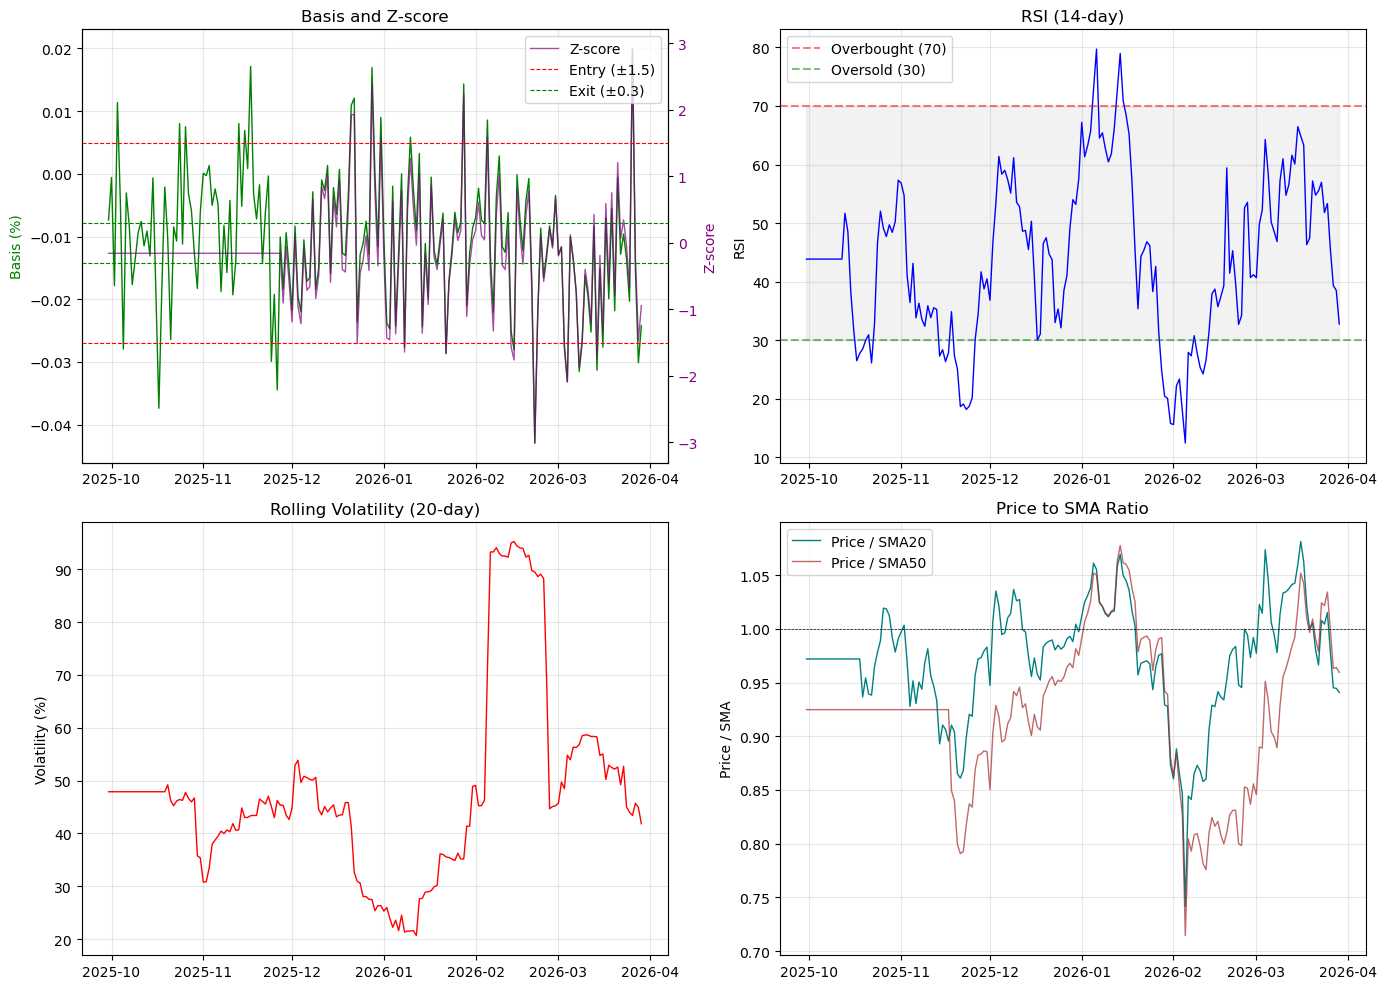

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Базис и Z-score
ax1 = axes[0, 0]
ax1.plot(df_clean['ts'], df_clean['basis_pct'], linewidth=1, color='green', label='Basis (%)')
ax1.set_ylabel('Basis (%)', color='green')
ax1.set_title('Basis and Z-score')
ax1.grid(True, alpha=0.3)

ax1_twin = ax1.twinx()
ax1_twin.plot(df_clean['ts'], df_clean['basis_zscore'], linewidth=1, color='purple', alpha=0.7, label='Z-score')
ax1_twin.axhline(y=1.5, color='red', linestyle='--', linewidth=0.8, label='Entry (±1.5)')
ax1_twin.axhline(y=-1.5, color='red', linestyle='--', linewidth=0.8)
ax1_twin.axhline(y=0.3, color='green', linestyle='--', linewidth=0.8, label='Exit (±0.3)')
ax1_twin.axhline(y=-0.3, color='green', linestyle='--', linewidth=0.8)
ax1_twin.set_ylabel('Z-score', color='purple')
ax1_twin.tick_params(axis='y', labelcolor='purple')
ax1_twin.legend(loc='upper right')

# 2. RSI
axes[0, 1].plot(df_clean['ts'], df_clean['rsi'], linewidth=1, color='blue')
axes[0, 1].axhline(y=70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
axes[0, 1].axhline(y=30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
axes[0, 1].fill_between(df_clean['ts'], 30, 70, alpha=0.1, color='gray')
axes[0, 1].set_ylabel('RSI')
axes[0, 1].set_title('RSI (14-day)')
axes[0, 1].legend(loc='upper left')
axes[0, 1].grid(True, alpha=0.3)

# 3. Волатильность
axes[1, 0].plot(df_clean['ts'], df_clean['volatility_20'] * 100, linewidth=1, color='red')
axes[1, 0].set_ylabel('Volatility (%)')
axes[1, 0].set_title('Rolling Volatility (20-day)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Price to SMA
axes[1, 1].plot(df_clean['ts'], df_clean['price_to_sma_20'], linewidth=1, color='teal', label='Price / SMA20')
axes[1, 1].plot(df_clean['ts'], df_clean['price_to_sma_50'], linewidth=1, color='brown', alpha=0.7, label='Price / SMA50')
axes[1, 1].axhline(y=1, color='black', linestyle='--', linewidth=0.5)
axes[1, 1].set_ylabel('Price / SMA')
axes[1, 1].set_title('Price to SMA Ratio')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
print(f"Форма нормализованных признаков: {features_scaled.shape}")
print(f"Среднее после нормализации: {features_scaled.mean(axis=0)[:5]}...")
print(f"Стандартное отклонение после нормализации: {features_scaled.std(axis=0)[:5]}...")
print(f"Минимальное значение: {features_scaled.min():.4f}")
print(f"Максимальное значение: {features_scaled.max():.4f}")

Форма нормализованных признаков: (181, 17)
Среднее после нормализации: [-1.84014866e-18  7.36059464e-18 -1.17769514e-16  1.17769514e-16
  9.81412618e-17]...
Стандартное отклонение после нормализации: [1. 1. 1. 1. 1.]...
Минимальное значение: -4.8530
Максимальное значение: 5.0138


Логика:
- Z > upper_threshold: сигнал +1 (short futures + long spot) - ожидаем снижения базиса
- Z < lower_threshold: сигнал -1 (long futures + short spot) - ожидаем роста базиса
- neutral_lower <= Z <= neutral_upper: сигнал 0 (закрыть позицию)
- иначе: сохраняем предыдущий сигнал

In [21]:
zscore_results = backtest_zscore_strategy(
    df_clean,
    initial_capital=cfg.baseline.initial_capital,
    window=cfg.features.zscore_window,
    upper_threshold=cfg.baseline.enter_zscore,
    lower_threshold=-cfg.baseline.enter_zscore,
    neutral_upper=cfg.baseline.exit_zscore,
    neutral_lower=-cfg.baseline.exit_zscore,
    transaction_cost=cfg.baseline.transaction_cost,
)

print("Результаты бэктестинга Z-score стратегии:")
print(f"Совокупная доходность: {zscore_results['total_return']:.2%}")
print(f"Коэффициент Шарпа: {zscore_results['sharpe_ratio']:.2f}")
print(f"Максимальная просадка: {zscore_results['max_drawdown']:.2%}")
print(f"Win Rate: {zscore_results['win_rate']:.2%}")
print(f"Количество сделок: {zscore_results['trades']}")
print(f"Транзакционные издержки: {zscore_results['transaction_costs_total']:.4f}")

Результаты бэктестинга Z-score стратегии:
Совокупная доходность: -2.35%
Коэффициент Шарпа: -6.38
Максимальная просадка: -2.35%
Win Rate: 22.81%
Количество сделок: 24
Транзакционные издержки: 0.0250


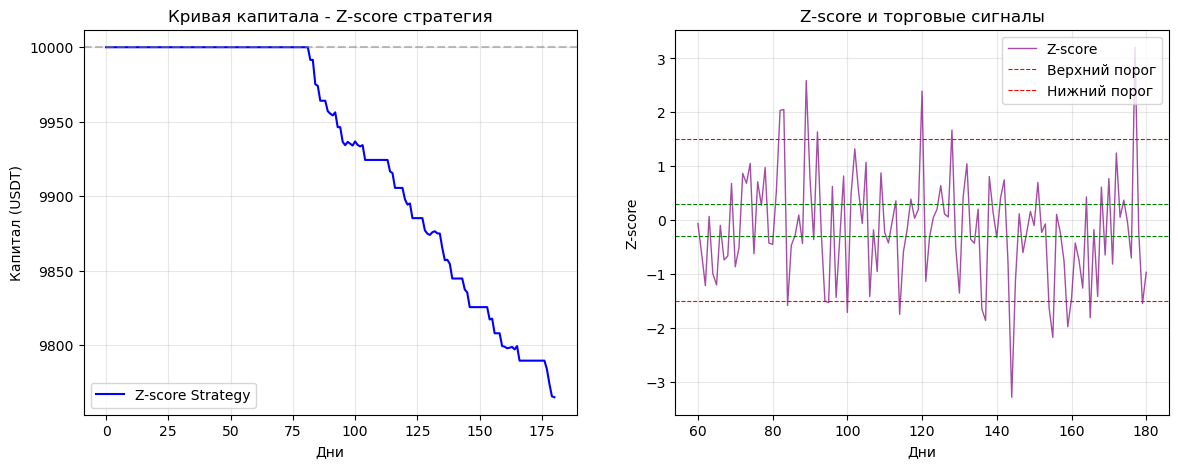

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
zscore_portfolio = zscore_results['portfolio']
ax1.plot(range(len(zscore_portfolio)), zscore_portfolio,
         linewidth=1.5, color='blue', label='Z-score Strategy')
ax1.axhline(y=10000, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Кривая капитала - Z-score стратегия', fontsize=12)
ax1.set_xlabel('Дни')
ax1.set_ylabel('Капитал (USDT)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
zscore_plot = zscore_results['zscore'].copy()
ax2.plot(zscore_plot, linewidth=1, color='purple', alpha=0.7, label='Z-score')
ax2.axhline(y=1.5, color='red', linestyle='--', linewidth=0.8, label='Верхний порог')
ax2.axhline(y=-1.5, color='red', linestyle='--', linewidth=0.8, label='Нижний порог')
ax2.axhline(y=0.3, color='green', linestyle='--', linewidth=0.8)
ax2.axhline(y=-0.3, color='green', linestyle='--', linewidth=0.8)
ax2.set_title('Z-score и торговые сигналы', fontsize=12)
ax2.set_xlabel('Дни')
ax2.set_ylabel('Z-score')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

In [23]:
baseline_files = sorted((repo_root / cfg.data.raw_dir).glob("baseline_*_merged.parquet"))
baseline_path = baseline_files[-1]

baseline_df = pd.read_parquet(baseline_path).sort_values("timestamp").reset_index(drop=True)
baseline_df = baseline_df.rename(columns={"timestamp": "ts"})

baseline_clean, baseline_scaled, baseline_scaler, baseline_feature_cols = build_feature_dataset(baseline_df)

save_processed_dataset(
    df_clean=baseline_clean,
    feature_cols=baseline_feature_cols,
    processed_dir=repo_root / cfg.data.processed_dir,
    dataset_name="baseline",
    scaler=baseline_scaler,
)

{'dataset_parquet': PosixPath('/Users/coyc_kari/Final_project_MLfr_team5/data/processed/baseline_feature_dataset.parquet'),
 'feature_columns_json': PosixPath('/Users/coyc_kari/Final_project_MLfr_team5/data/processed/baseline_feature_columns.json'),
 'scaler_pkl': PosixPath('/Users/coyc_kari/Final_project_MLfr_team5/data/processed/baseline_scaler.pkl')}

In [24]:
rl_files = sorted((repo_root / cfg.data.raw_dir).glob("rl_*_merged.parquet"))
rl_path = rl_files[-1]

rl_df = pd.read_parquet(rl_path).sort_values("timestamp").reset_index(drop=True)
rl_df = rl_df.rename(columns={"timestamp": "ts"})

rl_clean, rl_scaled, rl_scaler, rl_feature_cols = build_feature_dataset(rl_df)

save_processed_dataset(
    df_clean=rl_clean,
    feature_cols=rl_feature_cols,
    processed_dir=repo_root / cfg.data.processed_dir,
    dataset_name="rl",
    scaler=rl_scaler,
)

{'dataset_parquet': PosixPath('/Users/coyc_kari/Final_project_MLfr_team5/data/processed/rl_feature_dataset.parquet'),
 'feature_columns_json': PosixPath('/Users/coyc_kari/Final_project_MLfr_team5/data/processed/rl_feature_columns.json'),
 'scaler_pkl': PosixPath('/Users/coyc_kari/Final_project_MLfr_team5/data/processed/rl_scaler.pkl')}